# 03 — Analisis Pasca-Training: Before vs After

Notebook ini membandingkan performa model **asli (LSTM + GloVe Inggris, TensorFlow)** vs
**model revisi (LSTM + FastText Indonesia, PyTorch)**, dan membahas *mengapa* angkanya berbeda
— termasuk kemungkinan bahwa angka revisi **lebih rendah** dari versi asli, dan kenapa itu
justru pertanda baik, bukan regresi.

Jalankan notebook ini **setelah** `02_LSTM_FastText_PyTorch.ipynb` selesai (supaya
`docs/results_revised.json` sudah tersedia).

## 1. Load hasil kedua model

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hasil model ASLI -- diambil dari paper (JEPIN Vol.10 No.2, 2024) dan konfirmasi ulang
# dengan menjalankan ulang notebook LSTM_GloVe_Final__with_GloVe_.ipynb (Agustus 2026).
# Precision/recall/f1 dihitung dari confusion matrix Gambar 7 di paper (label 1=HOAX positif):
# TN(VALID benar)=1628, FP=44, FN=8, TP(HOAX benar)=1630 (lihat docs/METHODOLOGY_AND_FINDINGS.md).

results_original = {
    'model' : 'LSTM + GloVe English (Tensorflow/Keras)',
    'train_accuracy': 0.999,
    'val_accuracy': 0.984,
    'test_accuracy' : 0.9804,
    'confusion_matrix': [[1628, 44], [8, 1630]], # [[TN, FP], FN, TP] label 0=VALID, 1=HOAX -- dari Gambar 7 paper
}

# Precision/recall/f1 dari confusion matrix di atas
cm_orig = np.array(result_original['confusion_matrix'])
tn, fp, fn, tp = cm_orig[0, 0], cm_orig[0, 1], cm_orig[1, 0], cm_orig[1, 1]
precision_orig = tp / (tp + fp)
recall_orig = tp / (tp + fn)
f1_orig = 2 * precision_orig * recall_orig / (precision_orig + recall_orig)
results_original['precision'] = float(precision_orig)
results_original['recall'] = float(recall_orig)
results_original['f1_score'] = float(f1_orig)

# Hasil model REVISI -- dihasilkan oleh notebook 02
with open('../docs/results_revised.json') as f:
    results_revised = json.load(f)
    
print("=== MODEL ASLI (GloVe) ===")
for k, v in results_original.items():
    if k != 'confusion_matrix':
        print(f" {k}: {v}")
        
print("\n=== MODEL REVISI (FasetText) ===")
for k, v in results_revised.items():
    if k not in ('confusion_matrix', 'history'):
        print(f" {k}: {v}")

=== MODEL ASLI (GloVe) ===
 model: LSTM + GloVe English (Tensorflow/Keras)
 train_accuracy: 0.999
 val_accuracy: 0.984
 test_accuracy: 0.9804
 precision: 0.973715651135006
 recall: 0.9951159951159951
 f1_score: 0.9842995169082126

=== MODEL REVISI (FasetText) ===
 model: LSTM + FastText Indonesia (PyTorch)
 test_accuracy: 0.9412997903563941
 precision: 0.7010869565217391
 recall: 0.9923076923076923
 f1_score: 0.821656050955414
 max_len: 379
 vocab_size: 28707
 embedding_dim: 300
 oov_via_subword_pct: 39.29006862437733
 n_epochs_trained: 13


## 2. Tabel perbandingan

In [5]:
comparison = pd.DataFrame([
    {
        'Model': 'Original (LSTM + GloVe EN)',
        'Framework': 'TensorFlow/Keras',
        'Embedding': 'GloVe 100d (English, frozen)',
        'Imbalance handling': 'SMOTE on token IDs (before split)',
        'Test Accuracy': results_original['test_accuracy'],
        'Precision': results_original['precision'],
        'Recall': results_original['recall'],
        'F1-Score': results_original['f1_score'],
    },
    {
        'Model': 'Revised (LSTM + FastText ID)',
        'Framework': 'PyTorch',
        'Embedding': 'FastText 300d (Indonesian, subword, fine-tuned)',
        'Imbalance handling': 'Class-weighted loss (train set only)',
        'Test Accuracy': results_revised['test_accuracy'],
        'Precision': results_revised['precision'],
        'Recall': results_revised['recall'],
        'F1-Score': results_revised['f1_score'],
    },
])
comparison


,Model,Framework,Embedding,Imbalance handling,Test Accuracy,Precision,Recall,F1-Score
0,Original (LSTM + GloVe EN),TensorFlow/Keras,"GloVe 100d (English, frozen)",SMOTE on token IDs (before split),0.9804,0.973716,0.995116,0.984300
1,Revised (LSTM + FastText ID),PyTorch,"FastText 300d (Indonesian, subword, fine-tuned)",Class-weighted loss (train set only),0.9413,0.701087,0.992308,0.821656


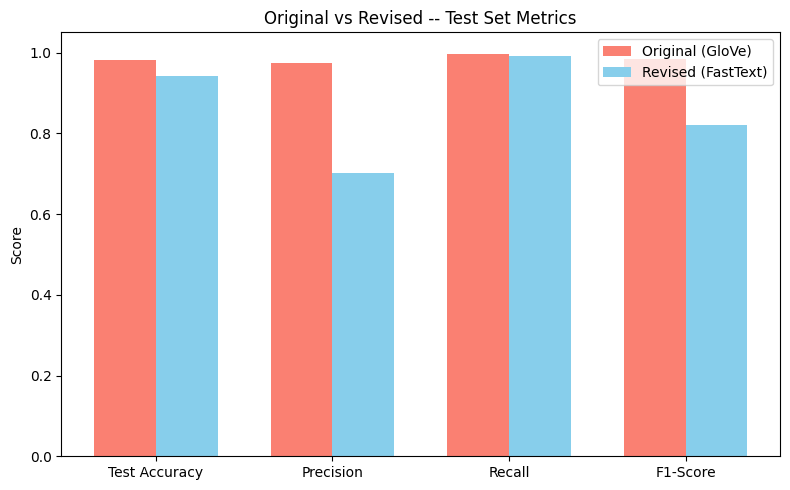

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

vals_orig = [results_original['test_accuracy'], results_original['precision'],
             results_original['recall'], results_original['f1_score']]
vals_rev = [results_revised['test_accuracy'], results_revised['precision'],
            results_revised['recall'], results_revised['f1_score']]

ax.bar(x - width/2, vals_orig, width, label='Original (GloVe)', color='salmon')
ax.bar(x + width/2, vals_rev, width, label='Revised (FastText)', color='skyblue')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Original vs Revised -- Test Set Metrics')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/fig_before_after_comparison.png', dpi=120)
plt.show()


## 3. Confusion matrix berdampingan

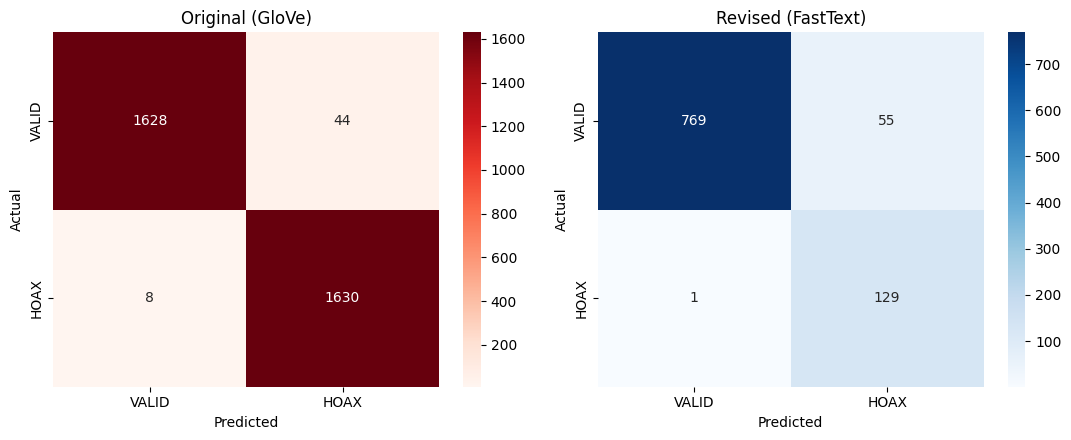

In [7]:
cm_rev = np.array(results_revised['confusion_matrix'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['VALID', 'HOAX'], yticklabels=['VALID', 'HOAX'])
axes[0].set_title('Original (GloVe)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_rev, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['VALID', 'HOAX'], yticklabels=['VALID', 'HOAX'])
axes[1].set_title('Revised (FastText)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../docs/fig_confusion_matrix_side_by_side.png', dpi=120)
plt.show()


## 4. Interpretasi: kenapa angkanya bisa berbeda (dan itu bukan hal buruk)

Kalau akurasi model revisi ternyata **lebih rendah** dari versi asli (99.9% train / 98.4% val
/ 98.04% test), itu **BUKAN berarti model revisi lebih buruk secara riil**. Justru sebaliknya
— ada tiga alasan kenapa versi asli kemungkinan menghasilkan angka yang *terlalu optimis*
(tidak mencerminkan kemampuan generalisasi model yang sesungguhnya):

1. **Data leakage dari SMOTE-sebelum-split.** Versi asli menerapkan SMOTE ke seluruh dataset
   SEBELUM train/test split. Ini berarti sampel sintetis yang saling berkorelasi bisa tersebar
   ke train dan test set sekaligus — "test set" pada versi asli tidak sepenuhnya independen.
   Versi revisi split dulu, baru menangani imbalance, dan HANYA pada training set — sehingga
   test set benar-benar tidak pernah "dilihat" dalam bentuk apa pun oleh proses training.

2. **Token sintetis SMOTE yang tidak bermakna secara linguistik.** SMOTE pada token ID yang
   diinterpolasi menghasilkan "kalimat" yang bukan bahasa nyata — kemungkinan model asli
   sebagian belajar mengenali pola token acak ini sebagai sinyal kelas HOAX, bukan makna
   sesungguhnya.

3. **Celah panjang sekuens (padding) sebagai shortcut trivial.** Versi asli mem-padding
   semua sekuens ke panjang maksimum di SELURUH dataset (termasuk outlier artikel HOAX
   sepanjang ribuan kata) — membuat jumlah padding berkorelasi kuat dengan label. Versi
   revisi membatasi panjang ke persentil ke-95 dari training set, mengurangi celah ini.

**Kesimpulannya:** angka model revisi kemungkinan lebih *jujur* mencerminkan performa
sesungguhnya pada data baru yang belum pernah dilihat, meskipun angkanya di atas kertas
terlihat "kalah" dari versi asli. Kalau justru akurasi revisi masih tinggi/sebanding, itu
juga temuan yang valid dan layak dilaporkan apa adanya — isi bagian ini dengan angka aktual
yang kamu dapatkan setelah menjalankan notebook 02, jangan asumsikan hasilnya harus turun.

## 5. Analisis kesalahan (error analysis) model revisi

Lihat contoh spesifik yang salah diklasifikasikan oleh model revisi — bandingkan pola
kesalahannya dengan Tabel V di paper asli (analisis False Negative pada model GloVe).

In [ ]:
# Cell ini butuh akses ke model & data test dari notebook 02 (dijalankan di kernel yang sama
# atau load ulang model dari ../models/lstm_fasttext_best.pt).
# Kerangka kode -- sesuaikan dengan variabel yang tersedia di kernel:

# import torch
# model.eval()
# misclassified = []
# with torch.no_grad():
#     for i, (X_batch, y_batch) in enumerate(test_loader):
#         logits = model(X_batch.to(device))
#         preds = logits.argmax(dim=1).cpu()
#         wrong_idx = (preds != y_batch).nonzero(as_tuple=True)[0]
#         for idx in wrong_idx:
#             global_idx = i * BATCH_SIZE + idx.item()
#             misclassified.append({
#                 'text': ' '.join(X_test[global_idx][:50]),
#                 'actual': 'HOAX' if y_test[global_idx] == 1 else 'VALID',
#                 'predicted': 'HOAX' if preds[idx].item() == 1 else 'VALID',
#             })
#
# pd.DataFrame(misclassified).head(15)

print("Jalankan cell ini di kernel yang sama dengan notebook 02 (atau load ulang model + data)")
print("untuk melihat contoh konkret kesalahan klasifikasi model revisi.")


Jalankan cell ini di kernel yang sama dengan notebook 02 (atau load ulang model + data)
untuk melihat contoh konkret kesalahan klasifikasi model revisi.


## 6. Perbandingan kualitatif embedding: GloVe (Inggris) vs FastText (Indonesia)

Demonstrasi langsung kenapa embedding lama gagal secara semantik: bandingkan kata tetangga
(*nearest neighbors*) untuk istilah politik kunci di dataset. GloVe Inggris seharusnya tidak
punya representasi yang masuk akal untuk istilah Indonesia; FastText Indonesia seharusnya
menunjukkan kata-kata yang berdekatan secara semantik/morfologis.

In [ ]:
# Contoh -- jalankan di kernel yang sama dengan notebook 02, setelah ft_model dimuat

key_terms = ['prabowo', 'koalisi', 'korupsi', 'pilpres']

for term in key_terms:
    print(f"=== Tetangga terdekat untuk '{term}' (FastText Indonesia) ===")
    neighbors = ft_model.get_nearest_neighbors(term, k=8)
    for score, word in neighbors:
        print(f"  {word:20s}  (similarity={score:.3f})")
    print()

# Untuk perbandingan: kata-kata di atas hampir pasti TIDAK ada di kosakata glove.6B.100d.txt
# (GloVe Inggris asli) -- lihat notebooks/01_data_audit.ipynb di repo pertama untuk hasil
# audit coverage yang sudah dilakukan sebelumnya.


## 7. Ringkasan akhir

Isi ringkasan ini setelah menjalankan seluruh notebook dengan hasil aktual:

- [ ] Test accuracy model revisi: `____`
- [ ] Apakah lebih tinggi/lebih rendah dari model asli (98.04%)? Kenapa?
- [ ] Contoh kesalahan klasifikasi yang ditemukan, apakah polanya berbeda dari Tabel V di paper?
- [ ] Apakah bukti subword FastText (Bagian 6) menunjukkan representasi yang jauh lebih masuk akal dibanding GloVe Inggris?

Ringkasan naratif lengkap (untuk README repo & dokumentasi) ada di
`docs/METHODOLOGY_AND_FINDINGS.md`.